<a href="https://colab.research.google.com/github/tuankhoin/CO3057-Computer-Vision/blob/main/Week_5_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt

Ho Chi Minh University of Technology (HCMUT)

CO3057 - Digital Image Processing and Computer Vision

# Week 5 - Features

## How CNNs Learn from Local Features
- CNNs learn from local features such as:
	- Textures
	- Edges
	- Local shapes
	- Changes in colour

## Approaches to Recognition
- Detect local features, ignore spatial position
	- Example: bag of words / bag of features
- Local features + weak spatial relations
	- Spatial pyramid models
- Detect local features and model spatial relations between them
	- Deformable-parts models
	- Keypoint tracking / matching

---
# 1. Local Features
---

## Bag of words
![](https://miro.medium.com/v2/resize:fit:1332/1*zexuwRcsawS3sBtXfEY9Vw.png)

- A count of the number of occurences of words in a sentence
- All structure between words is lost

## Bag of features
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/bag_of_features_histogram.png?raw=true)

- Take patches of an image -> Count occurences of those patterns
- Spatial relations removed

#### Problem: 1 feature can have varied looks
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/same_feature_different_looks.png?raw=true)

Solution: combine similar local features, e.g., k-means clustering

## Histogram Comparison
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/patch_histogram.png?raw=true)

We can take some patches, form a histogram of the matching patches in an image and use that to match the image

Problem: patches are **scale variant** → for varying scales from different images, performance will drop.

## Spatial Pyramids
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/room3.png?raw=true)
- Main idea: run bag of features at different dividing scales
- Adds a bit of spatial information, as you know where the patches are.

## Multiscale Pooling
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/multiscale_pooling.png?raw=true)
- Split an image into different scales, form a histogram counting those features in each patch

## Summary
- Bag of words/features = detect local features anywhere in the image, ignore local/spatial relations
- Spatial pyramids add **weak spatial relation information** to the "bag of features" approach
- Generally works well for category-level recognition - high variance to object translation and pose


---
# 2. Feature Detection
---

## Dense vs. Sparse Features
- Dense feature representation: compute local features everywhere
- Sparse feature representation: compute local features only at a few "important" points

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/dense_sparse_features.png?raw=true)

## Definitions
- **Feature detection**: finding "important" points (interest points or keypoints) in images
	- "Importance": Generally, points that can be detected reliably across image transformations
- **Feature descriptor**: a short code or set of numbers to represent a point in an image


## What Makes a Good Description?
- We have many points in an image, but we want to find the point that is causes the **most difference** in any direction away from the point.
	- This point is similar in every direction - not a good descriptor

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/descriptor1.png?raw=true)

  - The below point is better, but sliding along the roof will give a similar point, so still not the best

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/roof_point.png?raw=true)

  - The below point is different in every direction, so it makes a good descriptor

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/good_descriptor.png?raw=true)

## Selecting Good Keypoints
- Should be easy to recognise in a small window
- Shifting the window in any direction should produce a large change (intensity)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/sliding_window_descriptor.png?raw=true)



---
## The Mathematics of Corner Detection (not examinable)
<iframe width="560" height="315" src="https://www.youtube.com/embed/Z_HwkG90Yvw?si=7q92i5qkpjKoG7Lp" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>


- Change in appearance of window $w(x,y)$ for the shift $[u,v]$:
$$
E(u,v) = \sum_{x,y}w(x,y)[\underbrace{I(x+u,y+v)-I(x,y)}_{Change\;in\;intensity}]^2
$$

Common window functions: square, Gaussian

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/gaussian_kernel.png?raw=true)

As we can see in the change of window below, the intensity of the colours for each pixel changed when the window shifted to the upper right.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/window_error.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/change_in_wondow_error.png?raw=true)

- As we can see below, we will have the maximum value on corners, where the biggest change in colour intensities will occur.
- We can also see that for the errors, it is darkest along the edges, thus showing that the error is lowest along the edges.
- For the corner, there is no line, the darkest point is the corner.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/errors_along_edges.png?raw=true)

### Approximation
- Approximate shifted intensity using Taylor series:

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/corner_detection_mathematics.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/simplify_corner_math_formula.png?raw=true)

End of non-examinable part.

---

## Values of $M$
(From the tedious maths above) We have $M$ matrix representing changes in intensity. Remember image derivatives?
- We can see that taking the derivatives of different elements within the matrix along the $x$ and $y$ axis gives Sobel edge detection.
- We can also see the derivative in both axis gives us the diagonal edges in the image.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/values_of_m.png?raw=true)

## Corner Response Function
- Detect corners using eigenvalues $\lambda_1, \lambda_2$ of $M$
- We can see that for edges, the eigenvalue is large in one axis, but not for the other axis.
- **For the corner, the eigenvalues are large for both axes.**

⟹ Eigenvalues are what define a corner.

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/corner_response_function.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/corner_response.png?raw=true)

- To find corners, look for points where $\lambda_1\lambda_2$ is high, and $\lambda_1 + \lambda_2$ is low

---
# 3. Harris Corner Detection
---

- $\lambda_1\lambda_2$ and $\lambda_1 + \lambda_2$ are the determinant and trace of matrix $M$:
  - $det(M) = \lambda_1\lambda_2$
	  - `det = np.linalg.det(m)`    

  - $tr(M) = \lambda_1 + \lambda_2$
    - `trace = np.trace()`            
- Harris corner response: $R = det(M) - k(tr(\text(M))^2$
	- $k$ determined empirically, around 0.04 - 0.06

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/gray_room.png?raw=true)

#### Harris corner response = $det(M)-k(tr(M))^2$

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/harris_corner_response.png?raw=true)

#### Harris Corners

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/red_crosses.png?raw=true)

## Invariance / Tolerance
- Corner detection is based on the image gradient (edges), so it's
	- Invariant to translation
	- Invariant to rotation
	- Tolerant to changes in lighting
- Because the corner response is based on eigenvalues, it is invariant to image-plane rotation
- Not invariant to scale!

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/scale_variant.png?raw=true)

## Summary
- Rather than detecting local features everywhere, feature detectors can be used to find "important" points (interest points or keypoints)
- Common type of interest point = corners
- Corners can be detected from local gradients

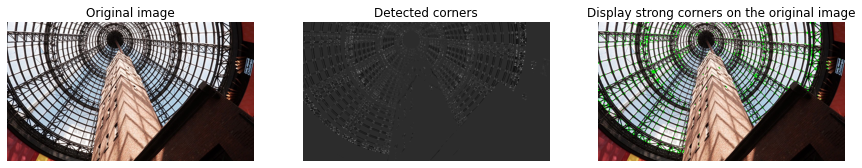

In [ ]:
# Read in an image from a filepath as graycsale.
rootpath='./'
img = cv2.imread(os.path.join(rootpath, "central.png"))

# detector parameters
block_size = 2
sobel_size = 3
k = 0.04

# Convert the colour from BGR to RGB for display
color_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert the colour to grayscale & 32-bit float
gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray_img = np.float32(gray_img)

# Detect corners with custom detector parameters
dst = cv2.cornerHarris(gray_img, block_size, sobel_size, k)

# Dilate corner image to enhance corner points, not necessary
#kernel = np.ones((3, 3), np.uint8) # The larger the size of the kernel, the greater the dilation
#dst = cv2.dilate(dst, kernel)
# Try to run the above codes to see what happens on the “Detected corners” map.

# Create a copy of the image and draw corners on it
corner_image = np.copy(color_img)

# Vary the threshold according to the image and the number of corners you want to detect
# The corners are drawn on the image if they pass the threshold
thresh = 0.1
corner_image[dst>thresh*dst.max()]=[0,255,0] # marking the corners in Green
# Try to change the threshold to see what happens.

plt.subplots(figsize=(15, 15))

plt.subplot(1,3,1)
plt.imshow(color_img)
plt.title('Original image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(dst, cmap='gray')
plt.title('Detected corners')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(corner_image)
plt.title('Display strong corners on the original image')
plt.axis('off')

plt.show()


---
# 4. Feature Descriptors: SIFT
---
- Having found keypoints in an image, we need a way to represent them
- Options:
	- Image patch
	- Handcrafted descriptors
		- SIFT
		- GLOH
		- BRISK
		- ORB
	- Machine-learned descriptors
		- DeTone, Malisiewicz, & Rabinovich (2018)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/feature_descriptors_cockatoo.png?raw=true)

## Scale-Invariant Feature Transform (SIFT)
<iframe width="560" height="315" src="https://www.youtube.com/embed/ram-jbLJjFg?si=C8MfwMxri5pweH-L" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>

- Compute gradient, take histograms in a grid of pixels around interest point
- Weight gradient magnitudes based on distance from centre of patch
- Normalise histograms to sum to 1

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/sift.png?raw=true)

## SIFT Implementation
- SIFT implementation details:
	- Patch size = 16 x 16
	- Grid = 4 x 4 cells
	- Histogram bins = 8 orientations
	- Gaussian weighting from centre of patch
	- Two-step normalisation: normalise to sum to 1, truncate values to 0.2, normalise to sum to 1
- Descriptor length = 4 x 4 x 8 = 128

- Interest points (blobs) are detected at multiple scales; descriptor is based on the scale with maximum response
- Histograms are encoded relative to the main orientation in the patch

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/normalised_histogram.png?raw=true)

## Summary
- Feature descriptor = a code to represent a local patch or interest point in an image
- Many handcrafted feature descriptors, with different:
	- Encoding method
	- Speed
	- Descriptor size
	- Feature detection method
 - Goal of feature descriptors is invariance, so points can be matched reliably across image transforms

 - Most recognition approaches are based on local features, but differ in how they represent spatial relations between features
	 - Bag-of-features methods: no spatial information
	 - Feature detection methods: precise spatial information
	- Choice of approach depends on task
		- Spatial information is probably not needed for category-level recognition
		- Spatial information is useful for tasks that require matching structure across images



---
# 5. Feature Matching
---
Basically matching same features across different angles!
![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/feature_matching.png?raw=true)

- Goal:
	- Simultaneously recognise object and its pose in 3D
	- Track features across multiple views
- Challenges
	- Features will have different appearances in each view (due to changes in pose, lighting, etc.)
	- Some features visible in one view may be missing in the other
	- Background could contain similar "matching" features

## Feature Matching as Model Fitting
- Not just looking for same features, but same spatial arrangement of features
- Model-fitting problem:
	- Propose a model that explains correspondence between matched points
	- Find points that fit the model parameters
- Problems:
	- Outliers (data not explained by model)
	- Noise in data that is explained by model

Hough Transform is one of the model fitting methods. We will come to that next!

---
# 6. Hough Transform
---
Traditional edge detection is not enough to get the lines (textures, broken lines,...)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/gray_room.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/canny_edge_map.png?raw=true)

## Mechanism
1. Each edge point "votes" for the lines that pass through that point
2. Identify lines with the most "votes" (i.e. can form a single straight line passing through all of them)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/hough_transform.png?raw=true)

- Identifying the parameters with most votes is easy if there is no noise in point locations
- Usually there is some noise
- Solution to noise: bin parameters + majority voting

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/line_voting.png?raw=true)


![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/bin_hough_transform.png?raw=true)

- Another problem: slope and intercept ($m,b$) are unbounded
- Solution: use **polar representation** of ($m,b$)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/hough_transform_sin.png?raw=true)

## Examples

The first image has the $m$ and $b$ as reasonably constant, so the point on the right is very concentrated in one point

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/example_hough_transform.png?raw=true)

The second one is a bit more noisy, so as we can see the Hough Transform concentrated point is now not so concentrated

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/example_hough_transform2.png?raw=true)

Now we have multiple concentrated lines of points, we can see that it forms multiple concentrated points in the Hough transform

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/example_hough_transform3.png?raw=true)





![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/canny_room_hough_transform.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/hough_lines.png?raw=true)

## Hough Transform Parameters
- Bin size
- Threshold for peaks
- Number of peaks (= number of lines)
- Minimum line/segment length
- Maximum allowed gap (to treat segments as the same line)

## Hough Transform Efficiency
- Hough transform is a grid search for parameters
- What happens as $N$ parameters increase?
	- Search space for Grid Search is $N \times N$ → Not good

## Summary
- Hough transform is a method for detecting structure in images
- Each pixel "votes" for parameters
- Common application:
	- Line detection
	- Circle detection
- Basically grid search over all possible values of each parameter, so limited to just a few parameters

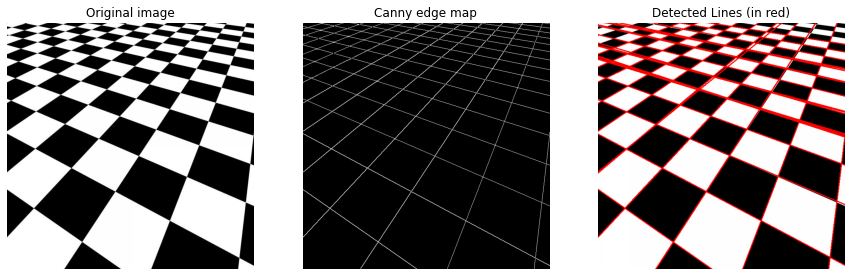

In [ ]:
checkerboard = cv2.imread(path + "checkerboard.png",cv2.IMREAD_GRAYSCALE)

# Canny edge detection with OpenCV
board_edge = cv2.Canny(checkerboard,50,250,apertureSize=3,L2gradient=True)

# Sandard Hough transform
lines = cv2.HoughLines(board_edge, 1, np.pi/180, 120)

# Convert the grayscale map to RGB format.
color_board = cv2.cvtColor(checkerboard, cv2.COLOR_GRAY2RGB)

# Drawing the lines
for line in lines:
    rho,theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    pt1 = (int(x0 + 1000*(-b)),int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)),int(y0 - 1000*(a)))
    # Draws a line segment connecting two points, colour=(255,0,0) and thickness=2.
    cv2.line(color_board,pt1,pt2,(255,0,0),2)


plt.subplots(figsize=(15, 15))

plt.subplot(1,3,1)
plt.imshow(checkerboard, cmap='gray')
plt.title('Original image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(board_edge, cmap='gray')
plt.title('Canny edge map')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(color_board)
plt.title("Detected Lines (in red)")
plt.axis('off')

plt.show()

Why sometimes there are 2 separated lines at a given line edge? That is because the image are in pixels (not sub-pixels), so the approximated lines from a same edge line might ended up approximated differently (in this case, too far away to be merged).

---
# 7. RANSAC
---
RANSAC = RANdom SAmple Consensus
- Like Hough transform, points "vote" for the **model** that explains those points
- Iteratively:
	1. Sample $N$ **points** at random (when $N$ is the number of points needed to **fit the model**)
	2. Calculate model **parameters**
	3. Count the **inliers**
  4. Best model = model with the most inliers
  5. Usual stopping criterion: max iter, rate threshold.

To use RANSAC on something, you need to define:
- The model (set)
- The points (elements)
- Minimum condition to form a set
- The metric (How to denote inliers/outliers)
## Example: RANSAC Line Fitting
- The model: Line
- The points: Points (no shit)
- Minimum condition to form a set: 2 points to make a line
- The metric: Euclidean distance to line < threshold

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_example.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_step1.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_step2.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_step3.png?raw=true)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_final.png?raw=true)

## Picking RANSAC Parameters

### Number of iterations
Consider this example:
> Half of your data is outliers, i.e. $P(Inlier) = 0.5$, and you want to fit a line. How many sampling attempts will be need at the minimum?
- It takes 2 good points for a line: $P(2\;Inliers) = 0.5^2 = 0.25$  
- Using Bernoulli trials:
  - Chance of getting at least 1 good pair after 8 trials: $1-(1-0.25)^8 \approx 0.9$.
  - Chance of getting at least 1 good pair after 16 trials: $1-(1-0.25)^{16} \approx 0.99$.
  
### Threshold for inliers
Choose $\delta$ so that a good point with noise is likely (e.g., prob=0.95) within threshold

---
# 8. View Transformations
---
- What we see in the below pictures is that the actual building inside the image is the same, but the actual perspective of the building to the camera is different.
- We can think of this as a transformation

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/what_model.png?raw=true)

How can points on a flat surface transform between two camera views?

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/possible_transformation.png?raw=true)

## Affine Transformations
- Affine transformation is any combination of translation, scale, rotation, and shear
- Examples are shown below:

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/affine_transformation.png?raw=true)

## Projective Transformation
- Projective transformation combines affine transformation with a projective warp
$$
\begin{bmatrix}
   x' \\  
   y' \\
   w'  
\end{bmatrix} =
\underset{\text{Projective}}{\begin{bmatrix}
   a & b & c \\
   d & e & f \\
   g & h & i
\end{bmatrix}}
\begin{bmatrix}
   x \\
   y \\
   w
\end{bmatrix}
$$

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/projective_transformation.png?raw=true)

## 2D Planar Transformations

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/2d_planar_transformations.png?raw=true)

## How Many Points To Determine?
- How many points do you need to define a projective transform?
- Projective transform can include any combination of scaling, rotation, affine shift, and projective warp

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/how_many_points.png?raw=true)

One point is insufficient to recognise any transform

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/one_points.png?raw=true)

Two points - can't distinguish between different combinations of scaling, shift, and warp

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/two_points.png?raw=true)

Three points - sufficient to recognise an affine-only transform, but can't distinguish between an affine-only and projective transforms

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/three_pointa.png?raw=true)

Four points - unique solution!

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/four_points.png?raw=true)

---
# 9. Application: Instance Recognition
---
Step 1. Find keypoints + descriptors in each image

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/step1_feature_matching.png?raw=true)

Step 2. Find candidate matches: for each keypoint in image 1, find most similar match in image 2 (e.g. Using SIFT)

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/step2_feature_matching.png?raw=true)

Step 3. Use RANSAC to find subset of matches that can be explained by a **transformation model**



## Feature Matching with RANSAC
- The model: Transformation matrix
- The points: Corresponding pairs of points between 2 images
- Minimum condition to form a set: 4 pairs of corresponding points between 2 pictures
- The metric: reprojection error < threshold

![](https://github.com/travisddavies/computer_vision_notes/blob/main/Images/ransac_feature_matching.png?raw=true)

## Summary
- Features matching with RANSAC finds matching keypoints across images
- Finds points across views, and computes the transformation that relates those points
- Applications:
	- Instance recognition
	- Video stabilisation
	- Panorama stabilisation
	- Finding planes, vanishing points, etc. in images
	- 3D reconstruction



Number of successful matches between two images:  13


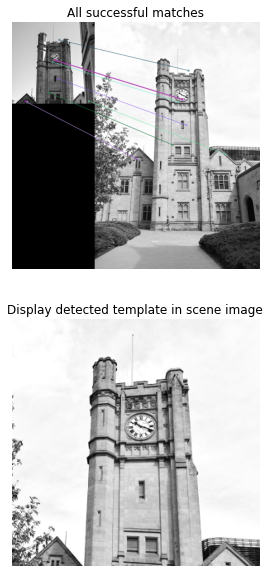

In [ ]:
unimelb1 = cv2.imread(path + "unimelb1.png", cv2.IMREAD_GRAYSCALE)
unimelb2 = cv2.imread(path + "unimelb2.png", cv2.IMREAD_GRAYSCALE)

# Initiate SIFT detector
sift = cv2.SIFT_create() # if cv2 version >= 4.4.0
# sift = cv2.xfeatures2d.SIFT_create() # if cv2 version = 4.3.x

# Compute SIFT keypoints and descriptors
kp1, des1 = sift.detectAndCompute(unimelb1,None)
kp2, des2 = sift.detectAndCompute(unimelb2,None)

# FLANN parameters and initialize
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params,search_params)

# Matching descriptor using KNN algorithm
matches = flann.knnMatch(des1,des2,k=2)

# Store all good matches as per Lowe's Ratio test.
good = []
for m,n in matches:
    if m.distance < 0.8*n.distance:
        good.append(m)

# Set a condition that at least MIN_MATCH_NUM matches are required to find the object.
MIN_MATCH_NUM = 4

if len(good)> MIN_MATCH_NUM:
    # If enough matches are found, we extract the positions of the matched keypoints in both images.
    # They are passed to find the perspective transformation.

    # Estimate homography between two images
    ptsA = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    ptsB = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    H, status = cv2.findHomography(ptsA,
                                   ptsB,
                                   cv2.RANSAC,
                                   ransacReprojThreshold = 5,
                                   maxIters = 200)

    matchesMask = status.ravel().tolist()

    # Draw detected template in scene image
    imgOut = cv2.warpPerspective(unimelb2, H, (unimelb1.shape[1],unimelb1.shape[0]),
                             flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)

    # Print total number of successful matches between two images
    print("\nNumber of successful matches between two images: ", matchesMask.count(1)) # Returns the number of 1 in the success list

else:
    # Otherwise, print that “Not enough matches are found”.
    print( "Not enough matches are found - {}/{}".format(len(good), MIN_MATCH_NUM) )
    matchesMask = None


# Draw our inliers (if successfully found the object) or all matching keypoints (if failed)
draw_params = dict(#matchColor = (0,255,0), # draw in a specific colour
                   #singlePointColor = (255,0,0), # draw in a specific colour
                   matchesMask = matchesMask, # draw only inliers
                   flags = 2)

success_matches = cv2.drawMatches(unimelb1,kp1,unimelb2,kp2,good,None,**draw_params)


# Plotting results
plt.subplots(figsize=(10, 10))

if matchesMask == None:
    plt.imshow(success_matches)
    plt.title('All matching keypoints')
    plt.axis('off')

else:
    plt.subplot(2,1,1)
    plt.imshow(success_matches)
    plt.title('All successful matches')
    plt.axis('off')

    plt.subplot(2,1,2)
    plt.imshow(imgOut, 'gray')
    plt.title('Display detected template in scene image')
    plt.axis('off')

plt.show()

---
# Exercises
---



## Question 1

We want to perform panorama stitching using homographies. We find a number of matches between the keypoints of two consecutive images, out of which at most **40% are outliers**. We run the RANSAC algorithm for **100 iterations**.

Derive a lower bound on the probability of correctly detecting the outliers (and hence correctly estimating the homography).

### Answer:

The relationship between:

- the probability of obtaining at least one all-inlier sample ($p$),
- the minimum number of point matches required to compute the transformation ($s$),
- the proportion of outliers ($e$),
- and the number of RANSAC iterations ($N$)

is given by:

$$
1 - p = \left(1 - (1 - e)^s \right)^N
$$


To accommodate for projection transforms, we will take $s$ as 4. And we will have:
- $s=4$
- $N=100$
- $e = 0.4$

$1-p = (1-(1-e)^s)^N$
$ = (1 - (1 - 0.4)^4)^{100}$
$ = (1 - 0.6^4)^{100}$
$\rightarrow p = 1 - (1 - 0.1296)^{100}$
$= 0.9999$

<iframe width="560" height="315" src="https://www.youtube.com/embed/EkYXjmiolBg?si=WnzbgX3GYVeNu5m-" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" allowfullscreen></iframe>

## Question 2

An application needs to find a circle of unknown size in an image. It operates as follows:

1. Detect edges
2. RANSAC:\
    (1)	Sample 3 edge points  
    (2) Fit a circle to those three points (three is enough to uniquely fit a circle)\
    (3)	Count consensus
    
3. Report circle with maximum consensus
    
### 2a. Formulate the RANSAC Problem
### 2b. If the circle in the image has 10% of the edge pixels, calculate how many RANSAC iterations are needed to find it with 99% probability.

- Chance of getting the good triplet (all 3 within the inlier set): $10\%^3 = 0.001$, which is 99.9% chance of missing out.

- We want 1% chance of missing out after n iterations, that is: $0.999^n = 0.01$. We just need to solve:

$n = \frac{log(0.01)}{log(0.999)} ≈ 4603$ iterations

### 2.c How might the algorithm be modified to improve the accuracy of the estimated centre and radius of the circle?

Just re-estimate using all inliers.